In [1]:
## 3.2.1 Configurer l’environnement et importer les packages Python
#Ce que vous allez faire:

#Préparation de votre environnement Python en important les bibliothèques nécessaires pour l’accès aux données, les opérations spatiales, la visualisation et les fonctions spécifiques à WOfS.
#_________________________________________________________

%matplotlib inline

import datacube                     # Client du datacube DE Africa  

import numpy as np                  # Opérations numériques 

import xarray as xr                 # Tableaux multidimensionnels

import geopandas as gpd             # Gestion des données vectorielles  

import matplotlib.pyplot as plt     # Visualisation graphique  

from IPython.display import Image   # Affichage d’animations

from matplotlib.colors import ListedColormap

from matplotlib.patches import Patch

import seaborn as sns

 

# Fonctions utilitaires de DE Africa

from odc.geo.geom import Geometry

from deafrica_tools.plotting import display_map, xr_animation

from deafrica_tools.spatial import xr_rasterize

from deafrica_tools.areaofinterest import define_area

#_________________________________________________________

In [2]:
## 3.2.2 Se connecter au Datacube
#Ce que vous allez faire:
#Établir une session nommée pour charger les produits DE Africa
#_________________________________________________________
dc = datacube.Datacube(app='Dam_water_extent')
#_________________________________________________________

In [4]:
## 3.2.3 Définir les paramètres d’analyse et la zone d'intérêt
#Ce que vous allez faire:

#Une zone d’étude rectangulaire sera définie autour du barrage de Theewaterskloof, et la période d’analyse multi-annuelle sera spécifiée.
#_________________________________________________________

# 1. Définir le centre du barrage de Theewaterskloof et le rayon (buffer)

central_lat = -34.031852    # degrés sud

central_lon =  19.216205    # degrés est

lat_buffer  = 0.08       # ~5 km

lon_buffer  = 0.09      # ~5 km

 

# 2. Calculer la boîte englobante (bounding box)

lat_range = (central_lat - lat_buffer, central_lat + lat_buffer)

lon_range = (central_lon - lon_buffer, central_lon + lon_buffer)

 

# 3. Définir les années d’analyse (de la sécheresse 2014–2017 jusqu’au remplissage en 2022)

start_year = '2014'

end_year   = '2022'

 

# 4. Définir le polygone de la zone d’intérêt (AOI) à l’aide d’un utilitaire (option : remplacer par un fichier shapefile

aoi = define_area(lat=central_lat, lon=central_lon,

                  lat_buffer=lat_buffer, lon_buffer=lon_buffer)

geopolygon = Geometry(aoi['features'][0]['geometry'], crs='epsg:4326')

geopolygon_gdf = gpd.GeoDataFrame(geometry=[geopolygon], crs=geopolygon.crs)

 

# 5. Afficher une carte interactive de votre zone d’étude

display_map(lon_range, lat_range)

#_________________________________________________________
#Figure 3.2.1:  Limite de la zone d’étude du barrage de Theewaterskloof

In [5]:
## 3.2.4 Charger le produit Annual Summer WOfS
#Ce que vous allez faire:
#Fetching the Landsat‐based WOfS annual frequency product for each year 2014–2022.
#_________________________________________________________

query = {

    'x': lon_range,

    'y': lat_range,

    'time': (start_year, end_year),

    'resolution': (-30, 30),

    'output_crs': 'EPSG:6933',

}


# Charger les résumé annuels de WOfS annual

ds = dc.load(product='wofs_ls_summary_annual', **query)


print(ds)
#_________________________________________________________

#Figure 3.2.2: Fréquence annuelle WOfS – Barrage Theewaterskloof (2014–2022)

<xarray.Dataset> Size: 24MB
Dimensions:      (time: 9, y: 567, x: 580)
Coordinates:
  * time         (time) datetime64[ns] 72B 2014-07-02T11:59:59.999999 ... 202...
  * y            (y) float64 5kB -4.088e+06 -4.088e+06 ... -4.105e+06 -4.105e+06
  * x            (x) float64 5kB 1.845e+06 1.845e+06 ... 1.863e+06 1.863e+06
    spatial_ref  int32 4B 6933
Data variables:
    count_wet    (time, y, x) int16 6MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    count_clear  (time, y, x) int16 6MB 0 0 0 0 0 0 0 0 ... 52 52 51 51 22 16 51
    frequency    (time, y, x) float32 12MB nan nan nan nan ... 0.0 0.0 0.0 0.0
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref


In [6]:
## 3.2.5 Découper selon la géométrie exacte du barrage
#Ce que vous allez faire:
#.Vectoriser votre polygone de zone d’intérêt (AOI) et appliquer un masque sur la base de données WOfS afin que les analyses ne couvrent que l’emprise réelle du barrage.
#_________________________________________________________

# Rasteriser le polygone de la zone d’intérêt 

aoi_raster = xr_rasterize(gdf=geopolygon_gdf, da=ds, crs=ds.crs)

 

# Masquer le jeu de données selon la zone d’intérêt rasterisée  

ds = ds.where(aoi_raster == 1)

#_________________________________________________________

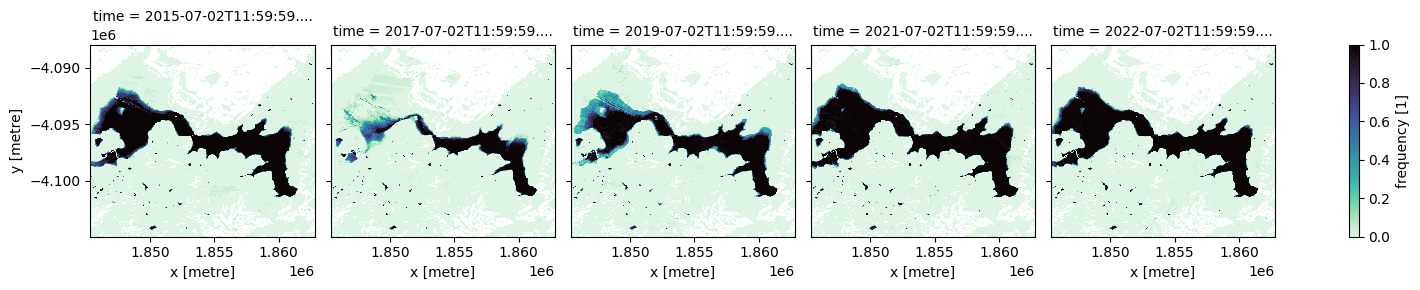

In [7]:
##  3.2.6 Visualiser la Fréquence Annuelle (Graphique en Facettes)
#Ce que vous allez faire:
#Visualiser une sélection d’années afin d'observer comment la fréquence de l’eau a changé pendant la sécheresse et la période de récupération.
#_________________________________________________________

# Afficher les cartes pour les années 2015, 2017, 2019, 2021, 2022

years_idx = [1, 3, 5, 7, 8]  # corresponding to 2015,17,19,21,22


ds.isel(time=years_idx).frequency.plot(col='time', col_wrap=5, cmap=sns.color_palette("mako_r", as_cmap=True));
#_________________________________________________________
#Figure 3.2.3: Annual Water Frequency Facet Plot (2015–2022)

Exporting animation to wofs_annual_frequency.gif


  0%|          | 0/9 (0.0 seconds remaining at ? frames/s)

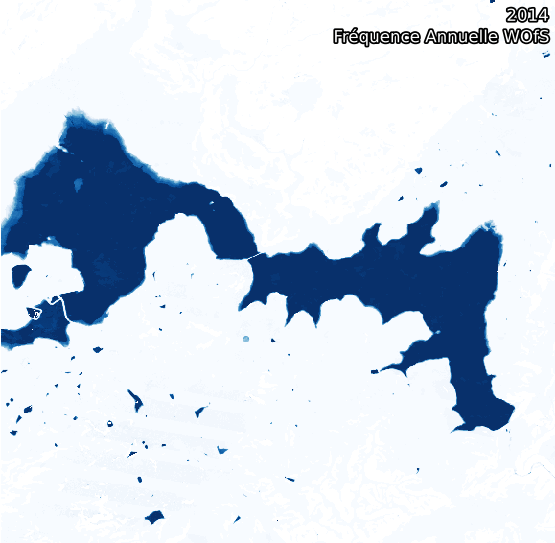

In [9]:
## 3.2.7 Créer une animation
#Ce que vous allez faire:
#Générer et afficher un GIF représentant la fréquence annuelle de l’eau de 2014 à 2022.
#_________________________________________________________

# Animer la bande de fréquence au fil du temps

xr_animation(

    ds=ds, 

    output_path='wofs_annual_frequency.gif',

    interval=500,

    bands=['frequency'],

    show_text='Fréquence Annuelle WOfS',

    show_date='%Y',

    width_pixels=400,

    annotation_kwargs={'fontsize':12},

    imshow_kwargs={'vmin':0, 'vmax':1, 'cmap':'Blues'},

    show_colorbar=False

)


# Afficher le GIF généré

plt.close()

Image(filename='wofs_annual_frequency.gif')

#_________________________________________________________
#Figure 3.2.4: Animation GIF montrant les changements annuels de la fréquence de l’eau de 2014 à 2022

In [10]:
## 3.2.8 Calculer l’étendue annuelle des plans d’eau
#Ce que vous allez faire:
#Convertir le nombre de pixels en kilomètres carrés en utilisant la résolution connue, puis tracer la série chronologique.
#_________________________________________________________

# Calculer la surface par pixel (km²)

pixel_length = query["resolution"][1]  # en mètres

m_per_km = 1000  # conversion de mètres en kilomètres

area_per_pixel = pixel_length**2 / m_per_km**2

#_________________________________________________________

In [12]:
#Seuil de fréquence WOfS annuelle pour classer les zones en eau / sans eau
#_________________________________________________________

# Seuil de fréquence > 0.20 pour considérer une zone comme “open water” 

water_threshold = 0.20

 

# Appliquer le seuil

 

water_extent = ds.frequency > water_threshold

 

# Calculer la surface (en km²)

ds_valid_water_area = water_extent.sum(dim=['x', 'y']) * area_per_pixel

#_________________________________________________________

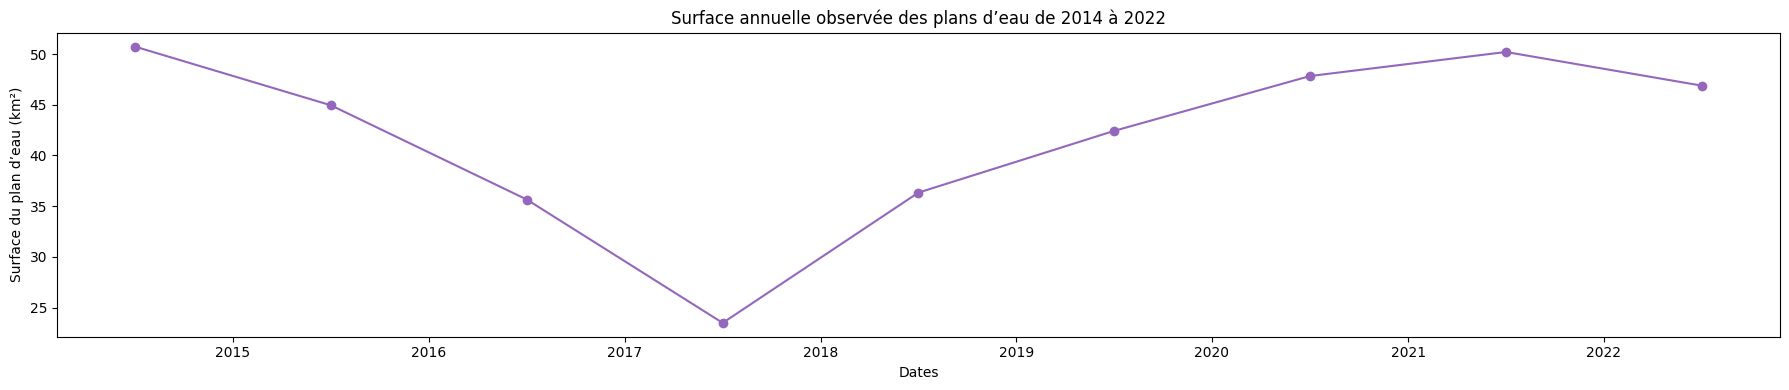

In [13]:
#Visualiser la surface annuelle d’eau libre
#_________________________________________________________

# Tracer la surface annuelle d’eau libre 

plt.figure(figsize=(18, 4))

ds_valid_water_area.plot(marker='o', color='#9467bd')

plt.title(f'Surface annuelle observée des plans d’eau de {start_year} à {end_year}')

plt.xlabel('Dates')

plt.ylabel('Surface du plan d’eau (km²)')

plt.tight_layout()

#_________________________________________________________
#Figure 3.2.5: Superficie annuelle des zones en eau libre (km²) observée de 2014 à 2022

In [14]:
3## .2.9 Identifier les années de minimum/maximum d’étendue d’eau et visualiser les cartes
#Ce que vous allez faire:
#Identifier les années avec la plus faible et la plus forte superficie en eau, puis visualiser l’emprise spatiale de ces deux années sur des cartes.
#_________________________________________________________

#  Trouver les années avec l’étendue d’eau minimale et maximale

min_water_area_date, max_water_area_date =  min(ds_valid_water_area), max(ds_valid_water_area)

time_xr = xr.DataArray([min_water_area_date.time.values, max_water_area_date.time.values], dims=["time"])


print(time_xr)
#_________________________________________________________
#Figure 3.2.6: Informations sur les années d’étendue d’eau minimale et maximale

<xarray.DataArray (time: 2)> Size: 16B
array(['2017-07-02T11:59:59.999999000', '2014-07-02T11:59:59.999999000'],
      dtype='datetime64[ns]')
Dimensions without coordinates: time


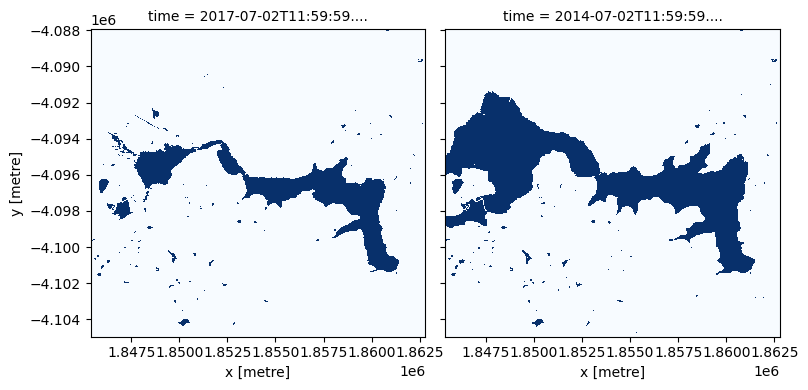

In [15]:
#Visualiser les dates correspondant aux années où l’étendue d’eau est minimale et maximale.
#_________________________________________________________

# Tracer le masque d’eau pour ces années 

water_extent.sel(time=time_xr).plot.imshow(

    col='time', col_wrap=2,

    cmap='Blues', add_colorbar=False,

    figsize=(8,4)

)

#_________________________________________________________
#Figure 3.2.7: Masque d’eau pour les années d’étendue minimale et maximale de l’eau

In [16]:
## 3.2.10 Comparer deux périodes de référence (2014 vs 2022)
#Ce que vous allez faire:
#Calculer les zones de gain, de perte et de stabilité de la surface en eau entre l’année de référence (2014) et l’année d’analyse (2022).
#_________________________________________________________

baseline_time = '2014'

analysis_time = '2022'

 

# Sélectionner les masques d’eau booléens et calculer le changement:  1 = gain, 0 = stable, -1 = loss

baseline_ds, analysis_ds = ds_valid_water_area.sel(time=baseline_time, method ='nearest'), ds_valid_water_area.sel(time=analysis_time, method ='nearest')

#_________________________________________________________

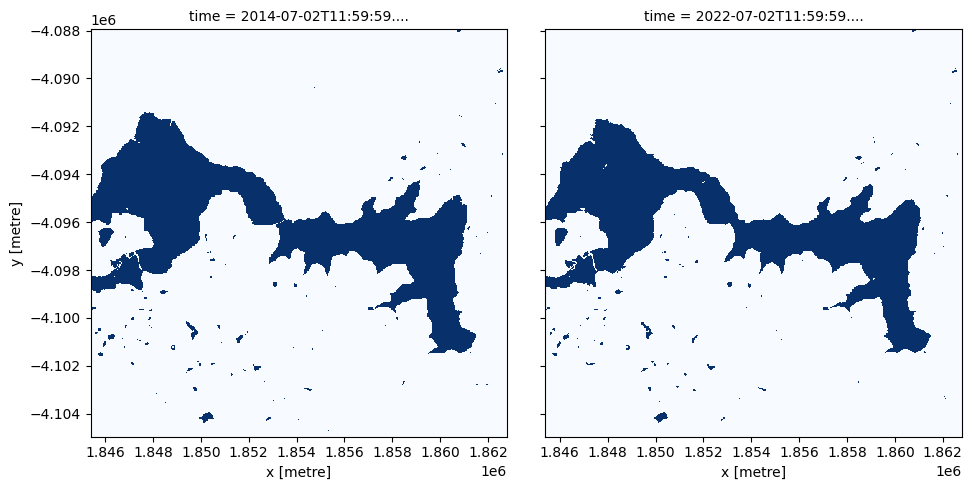

In [17]:

 #Visualiser l’étendue de l’eau pour les deux périodes sélectionnées.
#_________________________________________________________

compare = water_extent.sel(time=[baseline_ds.time.values, analysis_ds.time.values])


compare.plot(col="time",col_wrap=2,figsize=(10, 5), cmap='Blues', add_colorbar=False);
#_________________________________________________________
#Figure 3.2.8: Comparaison de l’étendue de l’eau (2014 et 2022)

In [19]:
# du changement entre les deux périodes sélectionnées

#La cellule ci-dessous calcule la quantité d’eau gagnée, perdue et restée stable entre les deux périodes
#_________________________________________________________

analyse_total_value = compare.isel(time=1).astype(int)

change = analyse_total_value - compare.isel(time=0).astype(int)

 

water_appeared = change.where(change == 1)

permanent_water = change.where((change == 0) & (analyse_total_value == 1))

permanent_land = change.where((change == 0) & (analyse_total_value == 0))

water_disappeared = change.where(change == -1)

#_________________________________________________________

In [20]:
#La cellule ci-dessous calcule la superficie des zones correspondant aux pertes d’eau (water_loss), aux gains (water_gain), à l’eau permanente et aux terres.
#_________________________________________________________

total_area = analyse_total_value.count().values * area_per_pixel

water_appeared_area = water_appeared.count().values * area_per_pixel

permanent_water_area = permanent_water.count().values * area_per_pixel

water_disappeared_area = water_disappeared.count().values * area_per_pixel

#_________________________________________________________

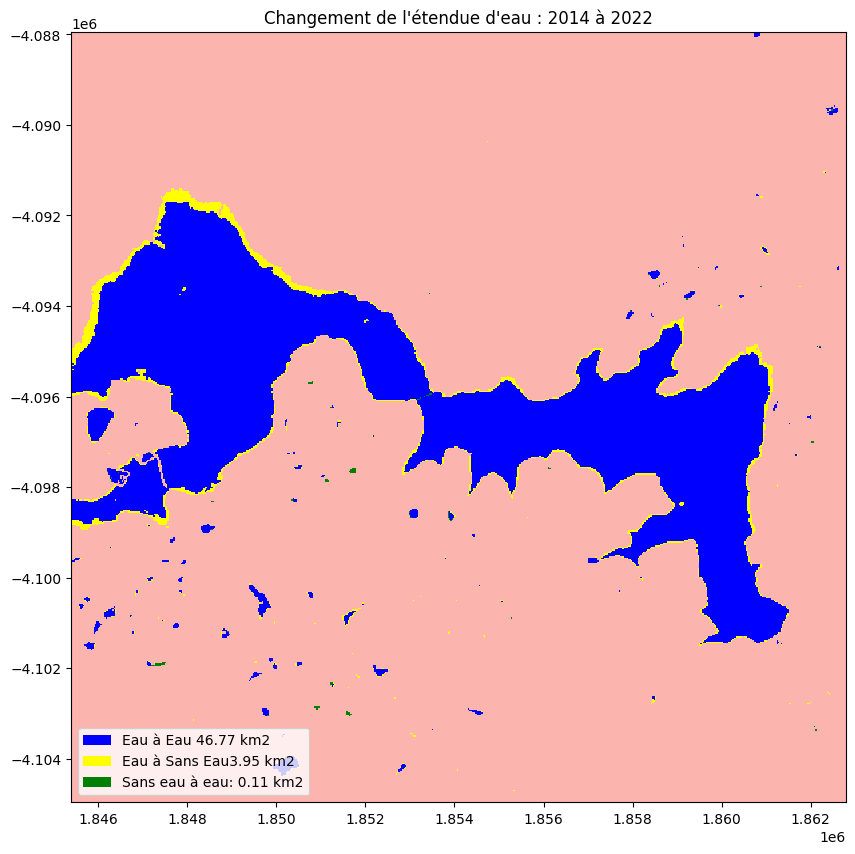

In [21]:
#Les variables liées à l’eau sont ensuite tracées pour visualiser les résultats.
#_________________________________________________________

water_appeared_color = "Green"

water_disappeared_color = "Yellow"

stable_color = "Blue"

land_color = "Brown"

 

fig, ax = plt.subplots(1, 1, figsize=(10, 10))

 

compare[1].plot.imshow(cmap="Pastel1",

                                       add_colorbar=False,

                                       add_labels=False,

                                       ax=ax)

water_appeared.plot.imshow(

    cmap=ListedColormap([water_appeared_color]),

    add_colorbar=False,

    add_labels=False,

    ax=ax,

)

water_disappeared.plot.imshow(

    cmap=ListedColormap([water_disappeared_color]),

    add_colorbar=False,

    add_labels=False,

    ax=ax,

)

permanent_water.plot.imshow(cmap=ListedColormap([stable_color]),

                            add_colorbar=False,

                            add_labels=False,

                            ax=ax)

 

plt.legend(

    [

        Patch(facecolor=stable_color),

        Patch(facecolor=water_disappeared_color),

        Patch(facecolor=water_appeared_color),

        Patch(facecolor=land_color),

    ],

    [

        f"Eau à Eau {round(permanent_water_area, 2)} km2",

        f"Eau à Sans Eau{round(water_disappeared_area, 2)} km2",

        f"Sans eau à eau: {round(water_appeared_area, 2)} km2",

    ],

    loc="lower left",

)


plt.title("Changement de l'étendue d'eau : " + baseline_time + " à " + analysis_time);
#_________________________________________________________
#Figure 3.2.9: Évolution de l’étendue des zones en eau entre 2014 et 2022 (Gain, Perte, Zones Stables)